In [178]:
from catboost import CatBoostRegressor
import backend.app.formulas as fr
import pandas as pd
import numpy as np

model = CatBoostRegressor()

model.load_model('export_models/model')

data = pd.read_csv("data/NET_2.csv")

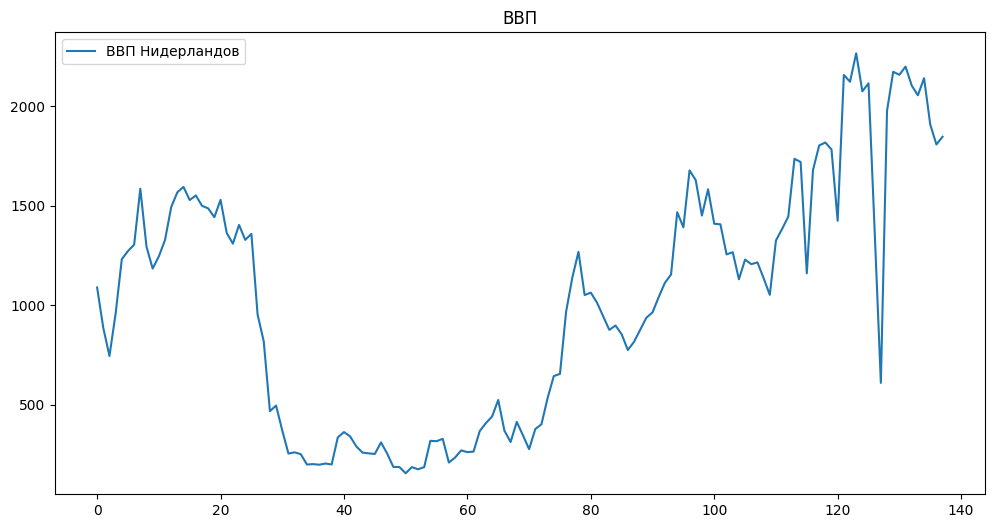

In [179]:
import matplotlib.pyplot as plt
gdp = data["gdp"].tolist()

plt.figure(figsize=(12, 6))
plt.plot(gdp, label="ВВП Нидерландов")
plt.legend()
plt.title("ВВП")
plt.show()

In [180]:
def create_seq(x_raw, raw_y):
    n = 12
    target = 4
    X = []
    y = []
    for i in range(len(x_raw) - n - target):
        X.append(x_raw[i:i+n])
        y.append(raw_y[i + n + target])
    return np.array(X), np.array(y)

def prepare_prediction(current_gdp, prediction):
    gdp = current_gdp * np.exp(prediction)
    return gdp

def get_pred12(gdp):
    temp = gdp[-1] / gdp[0]
    s = temp ** (1 / 11)
    return gdp[-1] * s ** 4

def get_pred2(gdp):
    temp = gdp[-1] / gdp[0]
    s = temp ** (1 / 1)
    return gdp[-1] * s ** 4

In [181]:
y_np_t = data["gdp"].values
X_np_t = data.drop(["date", "gdp", "gdp_per_cap", "consuption", "supply", "gdp_per_reg", "goverement", "most_popular_party", "flag_name"], axis=1).values
X_np_t.shape

(138, 31)

In [182]:
X, y = create_seq(X_np_t, y_np_t)
X = X.reshape(X.shape[0], -1)

In [183]:
print(data.drop(["date", "gdp", "gdp_per_cap", "consuption", "supply", "gdp_per_reg", "goverement", "most_popular_party", "flag_name"], axis=1).columns.tolist())


['population', 'money_activity', 'industrial_level', 'subside_percent', 'rentability', 'subside_pct', 'diversification', 'gold_income', 'country_savings', 'bank_savings', 'population_savings', 'money_mass', 'gini', 'fabric_employee', 'fabric_unemployement', 'rgo_employement', 'all_employemenent', 'all_free_work_places', 'fabric_worker_salary', 'capitalist_salary', 'literacy', 'military_budget', 'naval_budget', 'army_innov', 'naval_innov', 'country_size', 'population_per_reg', 'war_status', 'rich_tax', 'middle_tax', 'poor_tax']


In [184]:
prediction = model.predict(X)
classic_predict12 = []
classic_predict2 = []
true_pred = []
for i in range(len(prediction)):
    t = i + 12
    true_pred.append(prepare_prediction(gdp[t], prediction[i]))
    classic_predict2.append(get_pred2(gdp[t-1:t+1]))
    classic_predict12.append(get_pred12(gdp[t-11:t+1]))

true_pred = np.array(true_pred)

In [185]:
prediction.mean()

np.float64(0.006737103914438601)

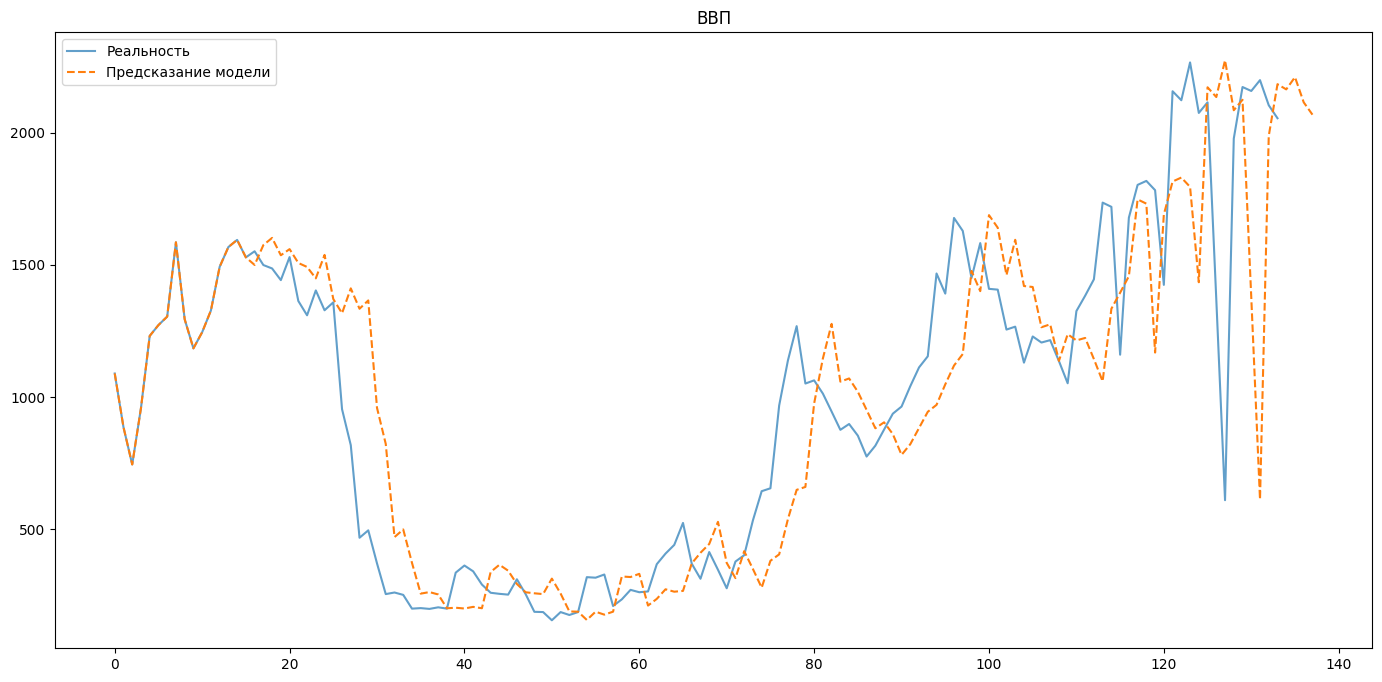

In [186]:
import matplotlib.pyplot as plt
gdp = data["gdp"].tolist()

plt.figure(figsize=(17, 8))
plt.plot(gdp[:-4], label="Реальность", alpha = 0.7)
plt.plot(gdp[:16] + list(true_pred), label="Предсказание модели", linestyle = '--')
plt.legend()
plt.title("ВВП")
plt.show()

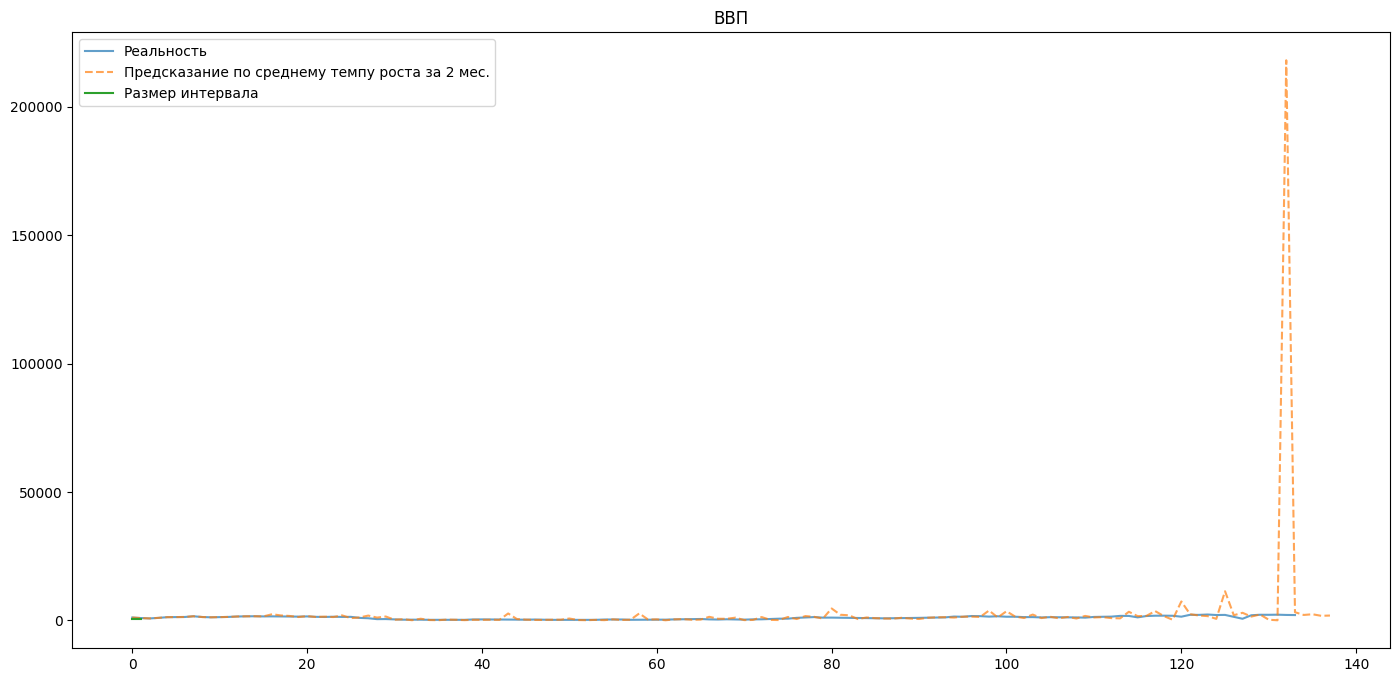

In [187]:
plt.figure(figsize=(17, 8))
plt.plot(gdp[:-4], label="Реальность", alpha = 0.7)
plt.plot(gdp[:16] + classic_predict2, label="Предсказание по среднему темпу роста за 2 мес.", linestyle = '--', alpha = 0.7)
plt.plot([500] * 2, label = "Размер интервала")
plt.legend()
plt.title("ВВП")
plt.show()

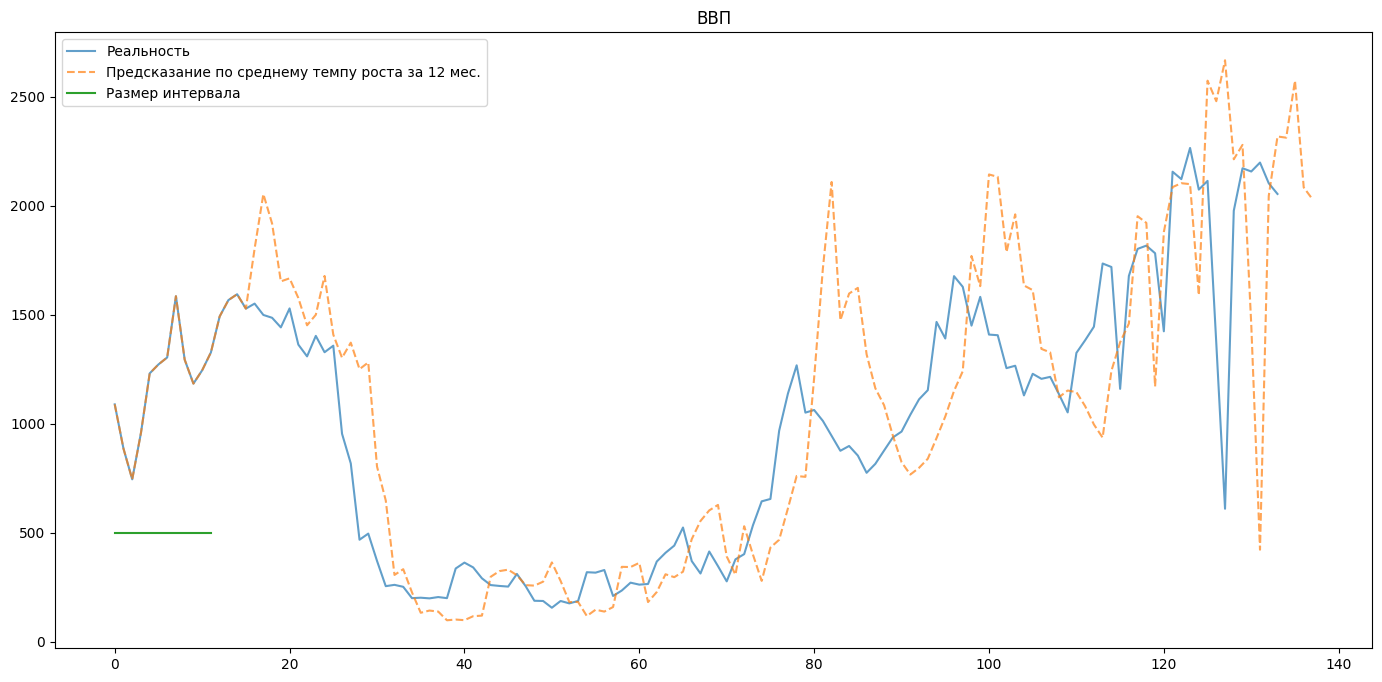

In [188]:
plt.figure(figsize=(17, 8))
plt.plot(gdp[:-4], label="Реальность", alpha = 0.7)
plt.plot(gdp[:16] + classic_predict12, label="Предсказание по среднему темпу роста за 12 мес.", linestyle = '--', alpha = 0.7)
plt.plot([500] * 12, label = "Размер интервала")
plt.legend()
plt.title("ВВП")
plt.show()

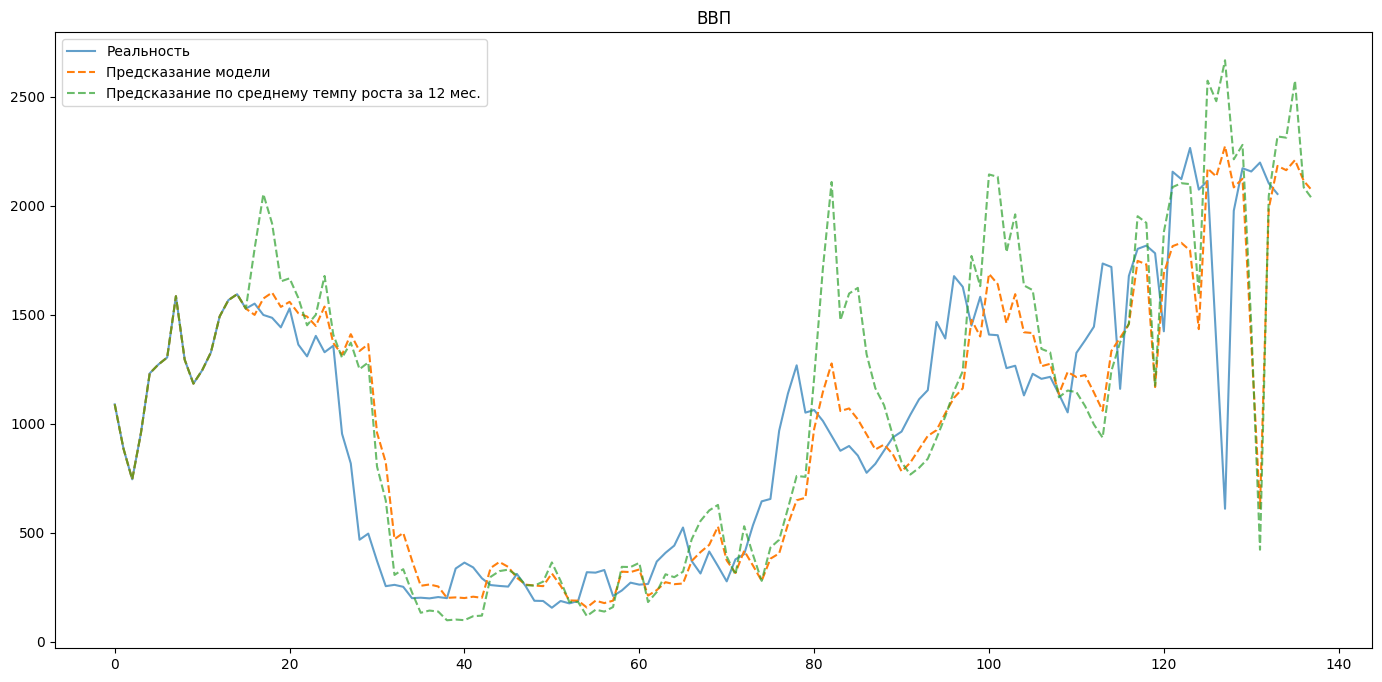

In [191]:
plt.figure(figsize=(17, 8))
plt.plot(gdp[:-4], label="Реальность", alpha = 0.7)
plt.plot(gdp[:16] + list(true_pred), label="Предсказание модели", linestyle = '--')
#plt.plot(gdp[:16] + classic_predict2, label="Предсказание по среднему темпу роста за 2 мес.", linestyle = '--', alpha = 0.7)
plt.plot(gdp[:16] + classic_predict12, label="Предсказание по среднему темпу роста за 12 мес.", linestyle = '--', alpha = 0.7)
plt.legend()
plt.title("ВВП")
plt.show()

In [192]:
print(prediction.mean())   # если близко к 0 — модель "ленится"
print(prediction.std())  

0.006737103914438601
0.0011642042990904439
